In [1]:
import pandas as pd

In [2]:
import numpy as np

In [4]:
covid = pd.read_csv("https://raw.githubusercontent.com/owid/covid-19-data/refs/heads/master/public/data/owid-covid-data.csv")

In [ ]:
#EDA DEL DATASET

In [63]:
#Locations uniche
locations_unique = covid['location'].unique()
print("Totale locations uniche: " + str(len(locations_unique)))

Totale locations uniche: 255


In [65]:
#Analisi dei continenti 
continent_analysis = covid['continent'].value_counts(dropna=False)
print(str("Distribuzione per continente:"))
print(continent_analysis)

Distribuzione per continente:
continent
Africa           95419
Europe           91031
Asia             84199
North America    68638
Oceania          40183
NaN              26525
South America    23440
Name: count, dtype: int64


In [70]:
# Locations senza continente (spesso aggregazioni)
no_continent = covid[covid["continent"].isna()]["location"].dropna().unique()
print("Locations SENZA continente (aggregazioni):", len(no_continent))
print("Prime 20 aggregazioni:")
for loc in sorted(no_continent)[:20]:
    print(" •", loc)
if len(no_continent) > 20:
    print(" ... e altre", len(no_continent) - 20)

Locations SENZA continente (aggregazioni): 12
Prime 20 aggregazioni:
 • Africa
 • Asia
 • Europe
 • European Union (27)
 • High-income countries
 • Low-income countries
 • Lower-middle-income countries
 • North America
 • Oceania
 • South America
 • Upper-middle-income countries
 • World


In [72]:
# Esempi di aggregazioni riconoscibili
aggregazioni_mondo = [loc for loc in no_continent if any(word in loc.lower() for word in ['world', 'international', 'union', 'income', 'bank'])]
print("Aggregazioni mondiali/economiche identificate str(len(aggregazioni_mondo)):")
for agg in sorted(aggregazioni_mondo)[:10]:
    print("  •", agg)

Aggregazioni mondiali/economiche identificate str(len(aggregazioni_mondo)):
  • European Union (27)
  • High-income countries
  • Low-income countries
  • Lower-middle-income countries
  • Upper-middle-income countries
  • World


In [31]:
# Statistiche descrittive
cases_stats = covid[['new_cases', 'total_cases']].describe()
print("Statistiche descrittive:")
print(cases_stats)

Statistiche descrittive:
          new_cases   total_cases
count  4.101590e+05  4.118040e+05
mean   8.017360e+03  7.365292e+06
std    2.296649e+05  4.477582e+07
min    0.000000e+00  0.000000e+00
25%    0.000000e+00  6.280750e+03
50%    0.000000e+00  6.365300e+04
75%    0.000000e+00  7.582720e+05
max    4.423623e+07  7.758668e+08


In [73]:
# Controllo logico: total_cases dovrebbe essere cumulativo, prendiamo alcuni paesi di verifica 
test_countries = ['Italy', 'Germany', 'France']
for country in test_countries:
    country_data = covid[
        (covid['location'] == country) &
        (covid['date'] >= '2020-03-01') &
        (covid['date'] <= '2020-03-10')    ].copy()
    if not country_data.empty:
        print("\n", country, " (marzo 2020):", sep="")
        print(country_data[['date', 'new_cases', 'total_cases']].head())



Italy (marzo 2020):
             date  new_cases  total_cases
185331 2020-03-01     1049.0       1128.0
185332 2020-03-02        0.0       1128.0
185333 2020-03-03        0.0       1128.0
185334 2020-03-04        0.0       1128.0
185335 2020-03-05        0.0       1128.0

Germany (marzo 2020):
             date  new_cases  total_cases
140467 2020-03-01      139.0        170.0
140468 2020-03-02        0.0        170.0
140469 2020-03-03        0.0        170.0
140470 2020-03-04        0.0        170.0
140471 2020-03-05        0.0        170.0

France (marzo 2020):
             date  new_cases  total_cases
130423 2020-03-01        0.0         16.0
130424 2020-03-02        0.0         16.0
130425 2020-03-03        0.0         16.0
130426 2020-03-04        0.0         16.0
130427 2020-03-05        0.0         16.0


In [144]:
# 3. IDENTIFICAZIONE PATTERN TEMPORALI
print("ANALISI TEMPORALE:")
print("-" * 60)
covid["date"] = pd.to_datetime(covid["date"], errors="coerce")
date_range = covid["date"].agg(["min", "max"])
print("Periodo coperto: dal", date_range["min"].strftime("%Y-%m-%d"),"al", date_range["max"].strftime("%Y-%m-%d"))
print("Durata totale:", (date_range["max"] - date_range["min"]).days, "giorni")


ANALISI TEMPORALE:
------------------------------------------------------------
Periodo coperto: dal 2020-01-01 al 2024-08-14
Durata totale: 1687 giorni


In [145]:
# Frequenza dei dati
date_counts = covid["date"].value_counts().describe()

print("Frequenza rilevazioni per data:")
print("  • Media locations per giorno:", round(date_counts["mean"]))
print("  • Min-Max locations per giorno:", round(date_counts["min"]), "-", round(date_counts["max"]))

Frequenza rilevazioni per data:
  • Media locations per giorno: 254
  • Min-Max locations per giorno: 2 - 261


In [76]:
# Paesi reali vs aggregazioni
countries_only = covid[covid["continent"].notna()]
aggregations_only = covid[covid["continent"].isna()]

print("Paesi reali (con continente):")
print("  • Righe:", len(countries_only))
print("  • Locations:", countries_only["location"].nunique())
print("  • Completezza total_cases:", round(countries_only["total_cases"].notna().sum() / len(countries_only) * 100, 1), "%")
print("  • Completezza new_cases:", round(countries_only["new_cases"].notna().sum() / len(countries_only) * 100, 1), "%")

print("\nAggregazioni (senza continente):")
print("  • Righe:", len(aggregations_only))
print("  • Locations:", aggregations_only["location"].nunique())
print("  • Completezza total_cases:", round(aggregations_only["total_cases"].notna().sum() / len(aggregations_only) * 100, 1), "%")

Paesi reali (con continente):
  • Righe: 402910
  • Locations: 243
  • Completezza total_cases: 97.2 %
  • Completezza new_cases: 96.8 %

Aggregazioni (senza continente):
  • Righe: 26525
  • Locations: 12
  • Completezza total_cases: 75.7 %


In [32]:
#Domanda 1: Analisi dimensioni

In [146]:
print("=== DIMENSIONI DEL DATASET ===")
print("Numero di righe:", format(covid.shape[0], ","))
print("Numero di colonne:", format(covid.shape[1], ","))
print("Dimensione totale:", format(covid.size, ","), "celle")

=== DIMENSIONI DEL DATASET ===
Numero di righe: 429,435
Numero di colonne: 67
Dimensione totale: 28,772,145 celle


In [147]:
# Info su tipi di dati
print("=== TIPI DI DATI ===")
data_types = covid.dtypes.value_counts()
for dtype, count in data_types.items():
    print(dtype, ":", count, "colonne", sep="")

=== TIPI DI DATI ===
float64:61colonne
object:4colonne
datetime64[ns]:1colonne
int64:1colonne


In [148]:
# Informazioni sui paesi/località
print("=== LOCALITA' ===")
print("Numero totale di paesi/regioni:", format(covid["location"].nunique(), ","))
print("Numero di continenti:", format(covid["continent"].nunique(), ","))

=== LOCALITA' ===
Numero totale di paesi/regioni: 255
Numero di continenti: 6


In [149]:
# Top 10 paesi
location_counts = covid["location"].value_counts()
print("Top 10 paesi per numero di record:")
print(location_counts.head(10))

Top 10 paesi per numero di record:
location
High-income countries            3026
European Union (27)              3024
Upper-middle-income countries    3013
Lower-middle-income countries    2983
Low-income countries             2724
East Timor                       2688
Faroe Islands                    2068
Asia                             1684
Malaysia                         1684
Europe                           1684
Name: count, dtype: int64


In [150]:
# Informazioni temporali
print("=== ANALISI PERIODO ===")
print("Data Min: " + str(covid["date"].min()))
print("Data Max: " + str(covid["date"].max()))
periodo_giorni = (covid["date"].max() - covid["date"].min()).days
print("Periodo totale: " + str(periodo_giorni) + " giorni")
print("Anni Tot: " + str(covid["date"].dt.year.nunique()))

=== ANALISI PERIODO ===
Data Min: 2020-01-01 00:00:00
Data Max: 2024-08-14 00:00:00
Periodo totale: 1687 giorni
Anni Tot: 5


In [82]:
#Domanda 2: Numero di casi da inizio pandemia 

In [92]:
covid["date"] = pd.to_datetime(covid["date"], errors="coerce")

continenti = ["Africa", "Asia", "Europe", "North America", "South America", "Oceania", "World"]

agg = covid[covid["iso_code"].astype(str).str.startswith("OWID_")].copy()
agg = agg[agg["location"].isin(continenti)].copy()
agg = agg.dropna(subset=["total_cases"]).copy()
agg = agg.sort_values("date")
finali = agg.groupby("location").tail(1)
tot_mondo = finali.loc[finali["location"] == "World", "total_cases"].iloc[0]

print("\n=== CASI TOTALI E % SUL MONDO PER CONTINENTE ===")

# stampo risultati per i soli continenti (escludo World)
solo_continenti = finali[finali["location"] != "World"].copy()
solo_continenti = solo_continenti.sort_values("total_cases", ascending=False)

for _, r in solo_continenti.iterrows():
    continente = r["location"]
    casi = r["total_cases"]
    perc = (casi / tot_mondo) * 100

    print("•", continente, "- casi totali:", format(int(casi), ","), "- % sul mondo:", round(perc, 2))


=== CASI TOTALI E % SUL MONDO PER CONTINENTE ===
• Asia - casi totali: 301,499,099 - % sul mondo: 38.86
• Europe - casi totali: 252,916,868 - % sul mondo: 32.6
• North America - casi totali: 124,492,666 - % sul mondo: 16.05
• South America - casi totali: 68,809,418 - % sul mondo: 8.87
• Oceania - casi totali: 15,003,352 - % sul mondo: 1.93
• Africa - casi totali: 13,145,380 - % sul mondo: 1.69


In [114]:
# Domanda 3: 
print(f"Casi totali - Inizio anno: {it_meas['total_cases'].iloc[0]:,.0f}")
print(f"Casi totali - Fine anno: {it_meas['total_cases'].iloc[-1]:,.0f}")
print(f"Incremento totale 2022: {it_meas['total_cases'].iloc[-1] - it_meas['total_cases'].iloc[0]:,.0f}")
print(f"Nuovi casi - Media giornaliera: {it_meas['new_cases'].mean():.0f}")
print(f"Nuovi casi - Massimo giornaliero: {it_meas['new_cases'].max():,.0f}")
print(f"Nuovi casi - Data del picco: {it_meas.loc[it_meas['new_cases'].idxmax(), 'date'].strftime('%Y-%m-%d')}")

Casi totali - Inizio anno: 5,622,431
Casi totali - Fine anno: 25,060,503
Incremento totale 2022: 19,438,072
Nuovi casi - Media giornaliera: 53255
Nuovi casi - Massimo giornaliero: 1,268,153
Nuovi casi - Data del picco: 2022-01-16


In [116]:
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [120]:
#Domanda :
covid['date'] = pd.to_datetime(covid['date'])
italy_2022 = covid[(covid['location'] == 'Italy') & (covid['date'].dt.year == 2022)].copy()
italy_2022_filtered = italy_2022[italy_2022['new_cases'].notna()].copy()
italy_2022_filtered = italy_2022_filtered.reset_index(drop=True)
print(f"Dati Italia 2022 - Totale giorni: {len(italy_2022)}")
print(f"Dati Italia 2022 - Giorni con misurazioni: {len(italy_2022_filtered)}")
print(f"Periodo: dal {italy_2022_filtered['date'].min().strftime('%Y-%m-%d')} al {italy_2022_filtered['date'].max().strftime('%Y-%m-%d')}")

Dati Italia 2022 - Totale giorni: 365
Dati Italia 2022 - Giorni con misurazioni: 365
Periodo: dal 2022-01-01 al 2022-12-31


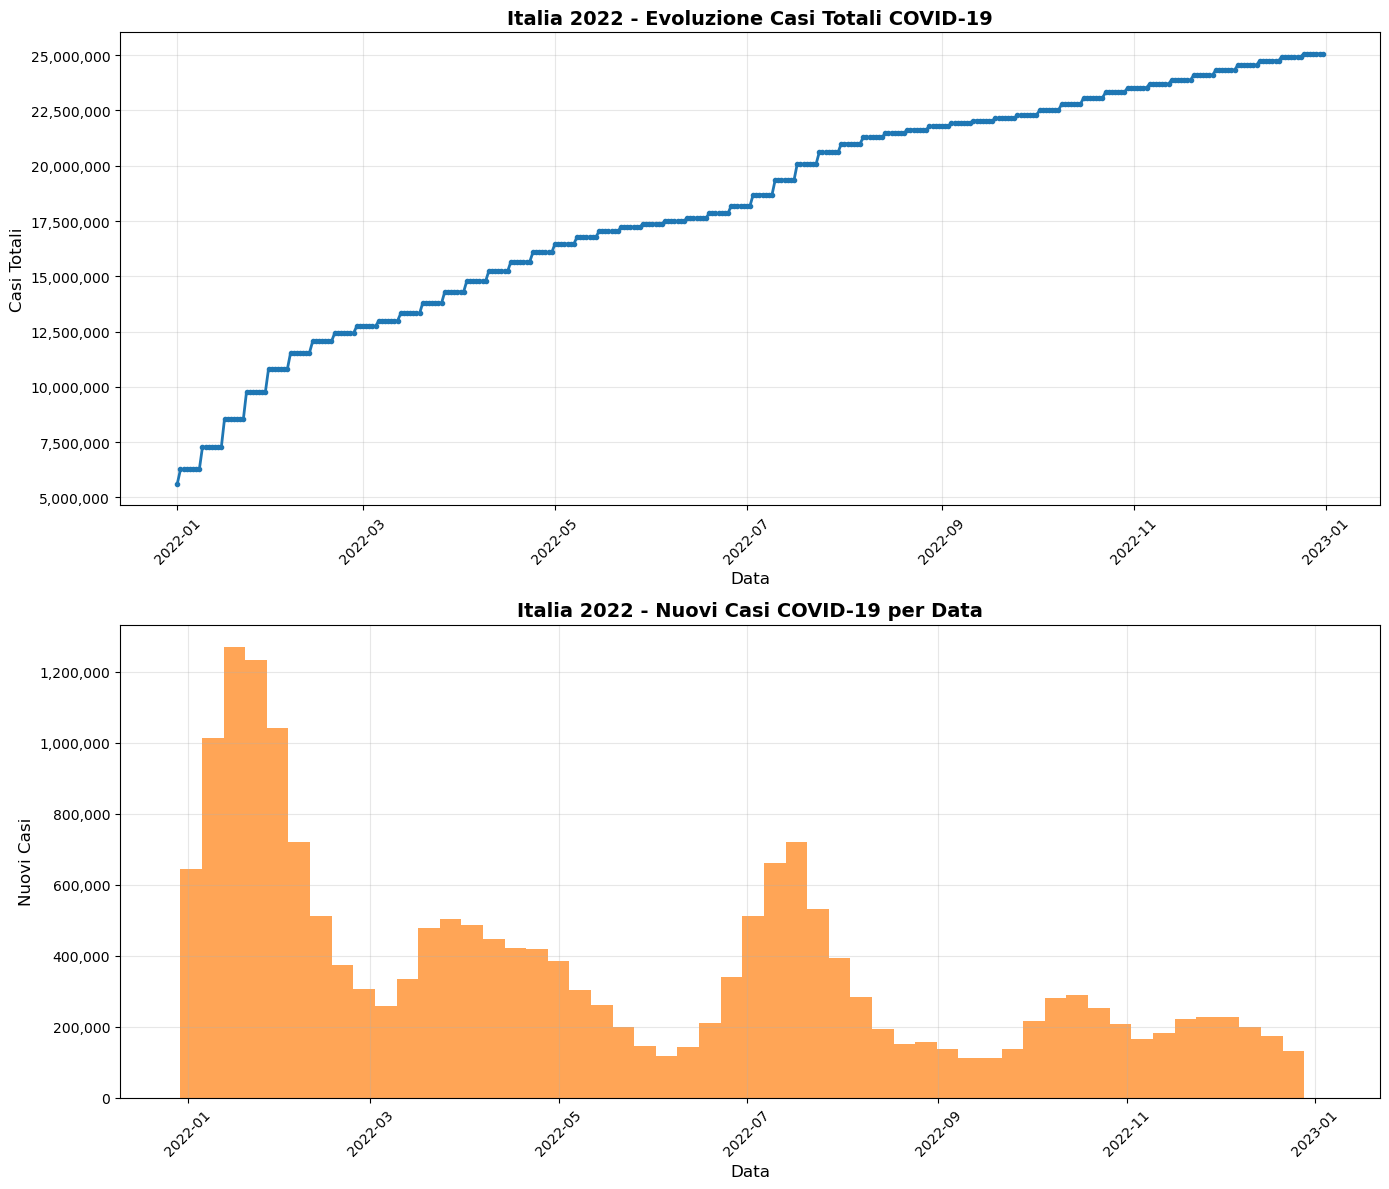

In [121]:
# Grafico 1 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))
ax1.plot(italy_2022_filtered['date'], italy_2022_filtered['total_cases'], 
         color='#1f77b4', linewidth=2, marker='o', markersize=3)
ax1.set_title('Italia 2022 - Evoluzione Casi Totali COVID-19', fontsize=14, fontweight='bold')
ax1.set_xlabel('Data', fontsize=12)
ax1.set_ylabel('Casi Totali', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.ticklabel_format(style='plain', axis='y')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
ax1.tick_params(axis='x', rotation=45)

#Grafico 2
ax2.bar(italy_2022_filtered['date'], italy_2022_filtered['new_cases'], 
        color='#ff7f0e', alpha=0.7, width=7)  # width=7 per giorni
ax2.set_title('Italia 2022 - Nuovi Casi COVID-19 per Data', fontsize=14, fontweight='bold')
ax2.set_xlabel('Data', fontsize=12)
ax2.set_ylabel('Nuovi Casi', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.ticklabel_format(style='plain', axis='y')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
ax2.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

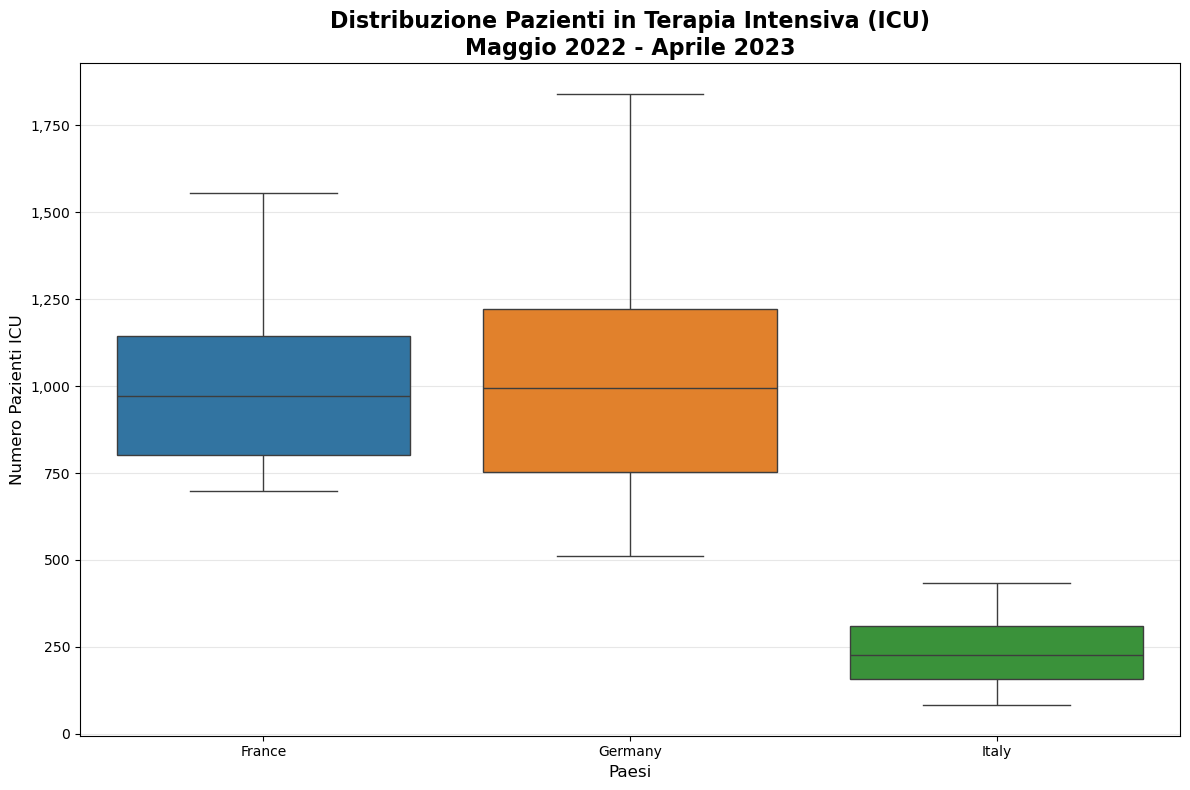

=== STATISTICHE PAZIENTI IN TERAPIA INTENSIVA ===
          count     mean  median     std    min     max
location                                               
France      335   998.38   972.0  220.15  699.0  1557.0
Germany     365  1022.39   994.0  306.11  512.0  1842.0
Italy       365   231.25   227.0   91.61   82.0   434.0

=== ANALISI VALORI NULLI ===
Italy: 0/365 nulli (0.0%)
Germany: 0/365 nulli (0.0%)
France: 30/365 nulli (8.2%)


In [151]:
# Filtro per i paesi richiesti e per il periodo maggio 2022 - aprile 2023
countries = ['Italy', 'Germany', 'France']
covid['date'] = pd.to_datetime(covid['date'])

# Filtro per il periodo specificato
start_date = '2022-05-01'
end_date = '2023-04-30'

covid_filtered = covid[(covid['location'].isin(countries)) & 
                 (covid['date'] >= start_date) & 
                 (covid['date'] <= end_date)]

# Rimuovo i valori nulli per il boxplot
covid_filtered = covid_filtered.dropna(subset=['icu_patients'])

# a. Creazione del boxplot - RISOLUZIONE ERRORE
plt.figure(figsize=(12, 8))

# Correzione per evitare il FutureWarning: assegno x a hue e uso legend=False
sns.boxplot(data=covid_filtered, x='location', y='icu_patients', 
            hue='location', palette=['#1f77b4', '#ff7f0e', '#2ca02c'], legend=False)

plt.title('Distribuzione Pazienti in Terapia Intensiva (ICU)\nMaggio 2022 - Aprile 2023', 
          fontsize=16, fontweight='bold')
plt.xlabel('Paesi', fontsize=12)
plt.ylabel('Numero Pazienti ICU', fontsize=12)

# Formattazione dell'asse Y
plt.ticklabel_format(style='plain', axis='y')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Calcolo statistiche descrittive per il commento
stats_summary = covid_filtered.groupby('location')['icu_patients'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(2)

print("=== STATISTICHE PAZIENTI IN TERAPIA INTENSIVA ===")
print(stats_summary)

# Analisi valori nulli per completezza
null_analysis = {}
for country in countries:
    country_data = covid[(covid['location'] == country) & 
                     (covid['date'] >= start_date) & 
                     (covid['date'] <= end_date)]
    total_records = len(country_data)
    null_count = country_data['icu_patients'].isna().sum()
    null_percentage = (null_count / total_records) * 100 if total_records > 0 else 0
    
    null_analysis[country] = {
        'total_records': total_records,
        'null_count': null_count,
        'null_percentage': null_percentage
    }

print("\n=== ANALISI VALORI NULLI ===")
for country, data in null_analysis.items():
    print(f"{country}: {data['null_count']}/{data['total_records']} nulli ({data['null_percentage']:.1f}%)")

# Risultato finale
result = {
    'statistiche_icu': stats_summary.to_dict(),
    'analisi_valori_nulli': null_analysis,
    'periodo_analisi': f"{start_date} to {end_date}",
    'boxplot_creato': True
}

In [131]:
#Domanda 5:
# Filtro per i paesi richiesti e per l'anno 2021
countries = ['Italy', 'Germany', 'France', 'Spain']

covid_filtered = covid[
    (covid['location'].isin(countries)) &
    (covid['date'].astype(str).str.startswith('2021'))
].copy()

# assicuro che hosp_patients sia numerico
covid_filtered['hosp_patients'] = pd.to_numeric(covid_filtered['hosp_patients'], errors='coerce')

# a. Calcolo la somma dei pazienti ospedalizzati per ogni paese
hosp_sum = covid_filtered.groupby('location')['hosp_patients'].sum(min_count=1)

# b. Analisi dei valori nulli
null_analysis = {}
for country in countries:
    country_data = covid_filtered[covid_filtered['location'] == country]
    total_records = len(country_data)
    null_count = country_data['hosp_patients'].isna().sum()
    null_percentage = (null_count / total_records) * 100 if total_records > 0 else 0

    null_analysis[country] = {
        'total_records': total_records,
        'null_count': int(null_count),
        'null_percentage': float(null_percentage)
    }

# Risultato finale
result = {
    'somma_pazienti_ospedalizzati': hosp_sum.to_dict(),
    'analisi_valori_nulli': null_analysis
}

# Stampo i risultati per visualizzazione (senza f-string)
print("=== SOMMA PAZIENTI OSPEDALIZZATI 2021 ===")
for country, total in result['somma_pazienti_ospedalizzati'].items():
    if pd.isna(total):
        print(country + ": dato mancante")
    else:
        print(country + ": " + format(total, ",.0f"))

print("\n=== ANALISI VALORI NULLI ===")
for country, data in result['analisi_valori_nulli'].items():
    print(
        country + ": " +
        str(data['null_count']) + "/" + str(data['total_records']) +
        " nulli (" + str(round(data['null_percentage'], 1)) + "%)"
    )

=== SOMMA PAZIENTI OSPEDALIZZATI 2021 ===
France: 6,008,717
Germany: dato mancante
Italy: 4,419,950
Spain: 2,411,706

=== ANALISI VALORI NULLI ===
Italy: 0/365 nulli (0.0%)
Germany: 365/365 nulli (100.0%)
France: 0/365 nulli (0.0%)
Spain: 0/365 nulli (0.0%)


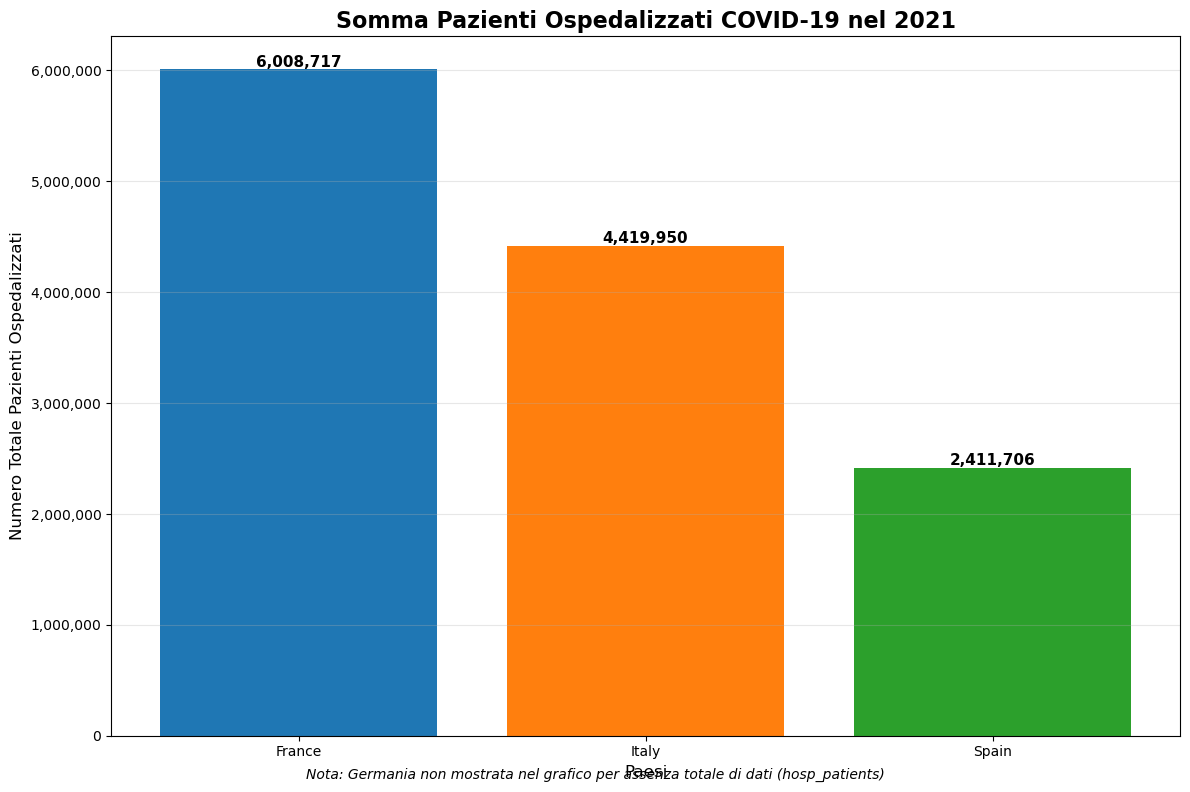

=== ANALISI VALORI NULLI ===
Italy: 0/365 nulli (0.0%)
Germany: 365/365 nulli (100.0%)
France: 0/365 nulli (0.0%)
Spain: 0/365 nulli (0.0%)


In [134]:
# Filtro per i paesi richiesti e per l'anno 2021
countries = ['Italy', 'Germany', 'France', 'Spain']

df_filtered = covid[
    (covid['location'].isin(countries)) &
    (covid['date'].astype(str).str.startswith('2021'))
].copy()

# Rendo numerico hosp_patients (se ci sono stringhe le mette a NaN)
df_filtered['hosp_patients'] = pd.to_numeric(df_filtered['hosp_patients'], errors='coerce')

# a. Calcolo la somma dei pazienti ospedalizzati per ogni paese
hosp_sum = df_filtered.groupby('location')['hosp_patients'].sum(min_count=1)

# b. Analisi dei valori nulli
null_analysis = {}
for country in countries:
    country_data = df_filtered[df_filtered['location'] == country]
    total_records = len(country_data)
    null_count = country_data['hosp_patients'].isna().sum()
    null_percentage = (null_count / total_records) * 100 if total_records > 0 else 0

    null_analysis[country] = {
        'total_records': int(total_records),
        'null_count': int(null_count),
        'null_percentage': float(null_percentage)
    }

# Creazione del grafico
plt.figure(figsize=(12, 8))

# Filtro solo i paesi con dati (somma > 0 e non NaN)
countries_with_data = hosp_sum.dropna()
countries_with_data = countries_with_data[countries_with_data > 0]

# Grafico a barre (4 colori, anche se magari non ci sono tutti i paesi)
bars = plt.bar(
    countries_with_data.index,
    countries_with_data.values,
    color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'][:len(countries_with_data)]
)

# Personalizzazione del grafico
plt.title('Somma Pazienti Ospedalizzati COVID-19 nel 2021', fontsize=16, fontweight='bold')
plt.xlabel('Paesi', fontsize=12)
plt.ylabel('Numero Totale Pazienti Ospedalizzati', fontsize=12)

# Aggiunta delle etichette sui valori delle barre
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        height,
        f'{height:,.0f}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

# Formattazione asse Y
plt.ticklabel_format(style='plain', axis='y')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# Nota: la Germania potrebbe non esserci se ha somma = 0 o tutta NaN
if 'Germany' not in countries_with_data.index:
    plt.figtext(
        0.5, 0.02,
        'Nota: Germania non mostrata nel grafico per assenza totale di dati (hosp_patients)',
        ha='center',
        fontsize=10,
        style='italic'
    )

plt.show()

# Stampo l'analisi dei valori nulli
print("=== ANALISI VALORI NULLI ===")
for country in countries:
    data = null_analysis[country]
    print(f"{country}: {data['null_count']}/{data['total_records']} nulli ({data['null_percentage']:.1f}%)")

# Risultato finale
result = {
    'somma_pazienti_ospedalizzati': hosp_sum.to_dict(),
    'analisi_valori_nulli': null_analysis,
    'grafico_creato': True
}

In [152]:
print("\n=== CONCLUSIONE GENERALE SU VALORI NULLI (dataset OWID) ===")
print("Nel dataset sono presenti valori nulli in diverse colonne e non tutte si gestiscono allo stesso modo.")
print("")
print("1) Colonne cumulative (es. total_cases, total_deaths):")
print("   - se mancano pochi giorni, spesso si puo' stimare con il valore precedente (forward fill),")
print("     perche' il cumulativo tende a crescere nel tempo.")
print("   - se mancano periodi lunghi, la sostituzione non e' affidabile e conviene limitare l'analisi.")
print("")
print("2) Colonne giornaliere o settimanali (es. new_cases, new_deaths, hosp_patients):")
print("   - i null possono indicare 'dato non riportato' (soprattutto con registrazioni settimanali).")
print("   - sostituire e' possibile solo per buchi piccoli e isolati;")
print("     se i null sono molti o ci sono settimane/mesi senza dati, meglio non imputare.")
print("")
print("3) Colonne derivate/rapporti (es. positivity_rate, reproduction_rate, indicatori per milione):")
print("   - dipendono da altri dati: imputarle puo' essere rischioso e introdurre distorsioni.")
print("   - in genere si lasciano null e si analizzano solo le date con valori presenti.")
print("")
print("In generale: se i valori nulli sono pochi e isolati si puo' valutare una sostituzione semplice;")
print("se sono molti o concentrati in periodi lunghi, e' meglio dichiarare la mancanza e non inventare dati.")


=== CONCLUSIONE GENERALE SU VALORI NULLI (dataset OWID) ===
Nel dataset sono presenti valori nulli in diverse colonne e non tutte si gestiscono allo stesso modo.

1) Colonne cumulative (es. total_cases, total_deaths):
   - se mancano pochi giorni, spesso si puo' stimare con il valore precedente (forward fill),
     perche' il cumulativo tende a crescere nel tempo.
   - se mancano periodi lunghi, la sostituzione non e' affidabile e conviene limitare l'analisi.

2) Colonne giornaliere o settimanali (es. new_cases, new_deaths, hosp_patients):
   - i null possono indicare 'dato non riportato' (soprattutto con registrazioni settimanali).
   - sostituire e' possibile solo per buchi piccoli e isolati;
     se i null sono molti o ci sono settimane/mesi senza dati, meglio non imputare.

3) Colonne derivate/rapporti (es. positivity_rate, reproduction_rate, indicatori per milione):
   - dipendono da altri dati: imputarle puo' essere rischioso e introdurre distorsioni.
   - in genere si lasciano 